In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import statistics as sts 
from matplotlib import pyplot as plt 
import joblib 
import streamlit as st 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import plot_tree,DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,precision_score,accuracy_score,f1_score
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df1=pd.read_csv(r"C:\Shravan\PythonPratice\supervised\Students Social Media Addiction.csv",encoding_errors="ignore")

In [4]:
df2=df1.copy()

In [5]:
df2.sample(10)

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
425,374,21,Male,Graduate,India,6.3,WhatsApp,Yes,6.0,5,In Relationship,4,8
622,568,22,Male,Graduate,Poland,3.6,Facebook,No,8.5,7,Single,2,5
53,165,19,Female,Undergraduate,Sri Lanka,5.1,Facebook,No,7.0,7,Single,2,5
488,649,21,Female,Undergraduate,UK,6.2,Twitter,Yes,6.3,5,Single,4,8
403,286,21,Male,Graduate,UK,5.0,Facebook,Yes,6.6,6,In Relationship,3,7
485,632,21,Male,Undergraduate,UK,6.2,Facebook,Yes,6.3,5,Single,4,8
247,283,20,Female,Undergraduate,South Korea,4.6,KakaoTalk,Yes,7.2,6,Single,3,6
283,427,20,Female,Undergraduate,USA,7.8,TikTok,Yes,4.5,5,In Relationship,4,9
227,203,20,Female,Undergraduate,Bangladesh,4.3,Instagram,Yes,7.6,5,Single,3,7
669,648,23,Male,Graduate,Canada,5.7,TikTok,Yes,6.6,6,Single,3,7


In [7]:
df2.columns

Index(['Student_ID', 'Age', 'Gender', 'Academic_Level', 'Country',
       'Avg_Daily_Usage_Hours', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Relationship_Status',
       'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')

In [8]:
df2.drop_duplicates(inplace=True)

In [9]:
df2.isna().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [10]:
df2.isnull().sum()

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

In [11]:
df2.ndim

2

In [12]:
df2.shape

(705, 13)

In [13]:
df2.size

9165

In [14]:
df2.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [15]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [27]:
numeric_columns=[]
cata_columns=[]


numeric=df2.select_dtypes(include=['number'],exclude=['object']).columns
numeric_columns.append(numeric)
print(numeric)

catagerical=df2.select_dtypes(include=['object'],exclude=['number']).columns
cata_columns.append(catagerical)
print(catagerical)


Index(['Student_ID', 'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score'],
      dtype='object')
Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Relationship_Status'],
      dtype='object')


In [44]:
df2.drop(columns=['Student_ID','Country'],axis=1,inplace=True)

In [43]:
df2['Relationship_Status'].value_counts().to_dict()

{'Single': 384, 'In Relationship': 289, 'Complicated': 32}

In [46]:
mapping_relation_status={
    'Single':1,
    "In Relationship":2,
    "Complicated":3
}

df2['Relationship_Status_encoded']=df2['Relationship_Status'].map(mapping_relation_status)

In [42]:
df2['Affects_Academic_Performance'].value_counts().to_dict()

{'Yes': 453, 'No': 252}

In [47]:
affetected_per={
    'Yes':1,
    'No':2
}
df2["Affects_Academic_Performance_encoded"]=df2['Affects_Academic_Performance'].map(affetected_per)

In [41]:
df2['Most_Used_Platform'].value_counts().to_dict()

{'Instagram': 249,
 'TikTok': 154,
 'Facebook': 123,
 'WhatsApp': 54,
 'Twitter': 30,
 'LinkedIn': 21,
 'WeChat': 15,
 'Snapchat': 13,
 'KakaoTalk': 12,
 'LINE': 12,
 'VKontakte': 12,
 'YouTube': 10}

In [48]:
most_used={
  'Instagram':1,
 'TikTok': 2,
 'Facebook': 3,
 'WhatsApp': 4,
 'Twitter': 5,
 'LinkedIn': 6,
 'WeChat': 7,
 'Snapchat': 8,
 'KakaoTalk': 9,
 'LINE': 10,
 'VKontakte': 11,
 'YouTube': 12  
    
}
df2['Most_Used_Platform_encoded']=df2['Most_Used_Platform'].map(most_used)

In [38]:
df2['Gender'].value_counts().to_dict()

{'Female': 353, 'Male': 352}

In [49]:
mapping_gender={
    "Female":2,
    "Male":1
}
df2["Gender_encoded"]=df2['Gender'].map(mapping_gender)

In [39]:
df2['Academic_Level'].value_counts().to_dict()

{'Undergraduate': 353, 'Graduate': 325, 'High School': 27}

In [50]:
mapping_acadamic={
    'Undergraduate': 2, 'Graduate': 3, 'High School': 1
}
df2['Academic_Level_enoded']=df2['Academic_Level'].map(mapping_acadamic)

In [51]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   705 non-null    int64  
 1   Gender                                705 non-null    object 
 2   Academic_Level                        705 non-null    object 
 3   Avg_Daily_Usage_Hours                 705 non-null    float64
 4   Most_Used_Platform                    705 non-null    object 
 5   Affects_Academic_Performance          705 non-null    object 
 6   Sleep_Hours_Per_Night                 705 non-null    float64
 7   Mental_Health_Score                   705 non-null    int64  
 8   Relationship_Status                   705 non-null    object 
 9   Conflicts_Over_Social_Media           705 non-null    int64  
 10  Addicted_Score                        705 non-null    int64  
 11  reslationship_statu

In [53]:
df3=df2.drop(columns=['Gender', 'Academic_Level', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Relationship_Status'],axis=1)

In [54]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   705 non-null    int64  
 1   Avg_Daily_Usage_Hours                 705 non-null    float64
 2   Sleep_Hours_Per_Night                 705 non-null    float64
 3   Mental_Health_Score                   705 non-null    int64  
 4   Conflicts_Over_Social_Media           705 non-null    int64  
 5   Addicted_Score                        705 non-null    int64  
 6   reslationship_status_encoded          705 non-null    int64  
 7   Relationship_Status_encoded           705 non-null    int64  
 8   Affects_Academic_Performance_encoded  705 non-null    int64  
 9   Most_Used_Platform_encoded            705 non-null    int64  
 10  Gender_encoded                        705 non-null    int64  
 11  Academic_Level_enod

In [55]:
df3.isna().sum()

Age                                     0
Avg_Daily_Usage_Hours                   0
Sleep_Hours_Per_Night                   0
Mental_Health_Score                     0
Conflicts_Over_Social_Media             0
Addicted_Score                          0
reslationship_status_encoded            0
Relationship_Status_encoded             0
Affects_Academic_Performance_encoded    0
Most_Used_Platform_encoded              0
Gender_encoded                          0
Academic_Level_enoded                   0
dtype: int64

In [71]:
class AnomoliesDetectionIQRMethod:
    def __init__(self,data):
        self.data=data
    def anomoliesfunction(self,column):
        Q1=self.data[column].quantile(0.25)
        Q3=self.data[column].quantile(0.75)
        IQR=Q3-Q1 
        left_portion=Q1-1.5*IQR 
        right_portion=Q3+1.5*IQR
        return (self.data[column]<left_portion) | (self.data[column]>right_portion)


AnomolieInstance=AnomoliesDetectionIQRMethod(df3)

for each_column in df3.columns:
    anomolies_data=AnomolieInstance.anomoliesfunction(each_column)
    anomlies_count=anomolies_data.sum()
    if anomolies_data.any():
        print(f"{each_column} --> {df3[each_column][anomolies_data].values} {anomlies_count}")
    else:
        print(f"{each_column} no anomiles data and {anomlies_count}")

Age no anomiles data and 0
Avg_Daily_Usage_Hours --> [8.5 8.4 1.5] 3
Sleep_Hours_Per_Night no anomiles data and 0
Mental_Health_Score no anomiles data and 0
Conflicts_Over_Social_Media no anomiles data and 0
Addicted_Score no anomiles data and 0
reslationship_status_encoded no anomiles data and 0
Relationship_Status_encoded no anomiles data and 0
Affects_Academic_Performance_encoded no anomiles data and 0
Most_Used_Platform_encoded --> [12 12 10 10 10 10 10 10 10 10 10 10 10 10 12 12 12  9  9  9  9  9  9  9
  9  9  9  9  9 12 12 12 12 12 11 11 11 11 11 11 11 11 11 11 11 11] 46
Gender_encoded no anomiles data and 0
Academic_Level_enoded no anomiles data and 0


In [77]:
# Method 2: Using apply for cleaner code
df4_clean = df3.copy()

# Create a mask that identifies rows with ANY anomalies
has_any_anomaly = pd.Series(False, index=df3.index)

for column in df3.columns:
    column_anomalies = AnomolieInstance.anomoliesfunction(column)
    has_any_anomaly = has_any_anomaly | column_anomalies

# Remove all rows with any anomalies
df4_clean = df3[~has_any_anomaly].copy()

df4_clean

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,reslationship_status_encoded,Relationship_Status_encoded,Affects_Academic_Performance_encoded,Most_Used_Platform_encoded,Gender_encoded,Academic_Level_enoded
0,18,3.0,7.0,7,1,4,1,1,2,12,1,1
1,18,4.0,6.5,7,1,5,1,1,2,2,1,1
2,18,6.5,5.5,5,4,9,1,1,1,1,2,1
3,18,5.3,5.5,5,4,8,1,1,1,2,1,1
4,18,5.4,5.4,5,4,8,3,3,1,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
699,24,4.5,7.3,7,2,5,2,2,2,5,1,3
700,24,6.2,6.3,5,4,8,1,1,1,3,1,3
702,24,5.9,6.5,6,3,7,1,1,1,1,1,3
703,24,4.8,7.1,7,2,5,2,2,2,3,1,3


In [79]:
df5=df4_clean.copy()

In [80]:
df5.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score',
       'reslationship_status_encoded', 'Relationship_Status_encoded',
       'Affects_Academic_Performance_encoded', 'Most_Used_Platform_encoded',
       'Gender_encoded', 'Academic_Level_enoded'],
      dtype='object')

In [81]:
df5.isna().sum()

Age                                     0
Avg_Daily_Usage_Hours                   0
Sleep_Hours_Per_Night                   0
Mental_Health_Score                     0
Conflicts_Over_Social_Media             0
Addicted_Score                          0
reslationship_status_encoded            0
Relationship_Status_encoded             0
Affects_Academic_Performance_encoded    0
Most_Used_Platform_encoded              0
Gender_encoded                          0
Academic_Level_enoded                   0
dtype: int64

In [89]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 676 entries, 0 to 704
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   676 non-null    int64  
 1   Avg_Daily_Usage_Hours                 676 non-null    float64
 2   Sleep_Hours_Per_Night                 676 non-null    float64
 3   Mental_Health_Score                   676 non-null    int64  
 4   Conflicts_Over_Social_Media           676 non-null    int64  
 5   Addicted_Score                        676 non-null    int64  
 6   reslationship_status_encoded          676 non-null    int64  
 7   Relationship_Status_encoded           676 non-null    int64  
 8   Affects_Academic_Performance_encoded  676 non-null    int64  
 9   Most_Used_Platform_encoded            676 non-null    int64  
 10  Gender_encoded                        676 non-null    int64  
 11  Academic_Level_enoded   

In [92]:
df5.drop(columns=['reslationship_status_encoded'],axis=1,inplace=True)

In [93]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 676 entries, 0 to 704
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age                                   676 non-null    int64  
 1   Avg_Daily_Usage_Hours                 676 non-null    float64
 2   Sleep_Hours_Per_Night                 676 non-null    float64
 3   Mental_Health_Score                   676 non-null    int64  
 4   Conflicts_Over_Social_Media           676 non-null    int64  
 5   Addicted_Score                        676 non-null    int64  
 6   Relationship_Status_encoded           676 non-null    int64  
 7   Affects_Academic_Performance_encoded  676 non-null    int64  
 8   Most_Used_Platform_encoded            676 non-null    int64  
 9   Gender_encoded                        676 non-null    int64  
 10  Academic_Level_enoded                 676 non-null    int64  
dtypes: float64(2), int64(9)


In [94]:
df5.sample(10)

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Relationship_Status_encoded,Affects_Academic_Performance_encoded,Most_Used_Platform_encoded,Gender_encoded,Academic_Level_enoded
697,24,5.4,6.8,6,3,7,2,1,5,1,3
34,19,4.7,5.8,6,3,7,3,1,2,2,2
532,22,4.7,4.5,6,4,8,2,1,2,1,3
488,21,6.2,6.3,5,4,8,1,1,5,2,2
58,19,4.6,7.0,5,3,7,1,1,1,2,2
626,22,5.7,6.8,6,3,7,1,1,5,1,3
274,20,4.5,7.4,6,3,7,1,1,2,2,2
223,20,5.9,5.2,6,4,8,1,1,2,2,2
176,19,6.2,6.3,5,4,8,1,1,3,2,2
390,21,5.7,6.5,5,3,8,2,1,2,1,3


In [95]:
df5['Affects_Academic_Performance_encoded'].value_counts().to_dict()

{1: 432, 2: 244}

In [96]:
df5.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score',
       'Relationship_Status_encoded', 'Affects_Academic_Performance_encoded',
       'Most_Used_Platform_encoded', 'Gender_encoded',
       'Academic_Level_enoded'],
      dtype='object')

In [97]:
df6=pd.DataFrame(data=df5,columns=['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score',
       'Relationship_Status_encoded',
       'Most_Used_Platform_encoded', 'Gender_encoded',
       'Academic_Level_enoded',"Affects_Academic_Performance_encoded"])

In [ ]:
x=df6.iloc[:,:-1]
y=df6.iloc[:,-1]

0      2
1      2
2      1
3      1
4      1
      ..
699    2
700    1
702    1
703    2
704    2
Name: Affects_Academic_Performance_encoded, Length: 676, dtype: int64

In [100]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [101]:
logistic_regression=LogisticRegression(solver='liblinear')

In [105]:
#cross score for logistic

cross_score=cross_val_score(logistic_regression,x,y,cv=10,scoring='accuracy')
mean_accuracy=np.mean(cross_score)
print(mean_accuracy)
print(cross_score)

0.9808823529411764
[1.         1.         1.         0.80882353 1.         1.
 1.         1.         1.         1.        ]


In [114]:
Decesion_tree=DecisionTreeClassifier(criterion='gini',min_samples_leaf=6,min_samples_split=10,max_depth=10,max_leaf_nodes=4)

In [116]:
params_grid={
    'criterion':['gini','entropy'],"max_depth":[2,4,6,8,10],"min_samples_split":[5,10,20,40,50,60,100]
}
grid_search=GridSearchCV(estimator=Decesion_tree,param_grid=params_grid,cv=10,scoring='accuracy',n_jobs=-1)

grid_search

,estimator,DecisionTreeC...ples_split=10)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 4, ...], 'min_samples_split': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [119]:
grid_search.fit(x,y)
print(grid_search.best_score_)
print(grid_search.best_estimator_)

0.9970588235294118
DecisionTreeClassifier(max_depth=2, max_leaf_nodes=4, min_samples_leaf=6,
                       min_samples_split=5)


In [124]:
spearmen1=df5.corr(method='spearman').round(2)

In [123]:
pearson1=df5.corr(method='pearson').round(2)

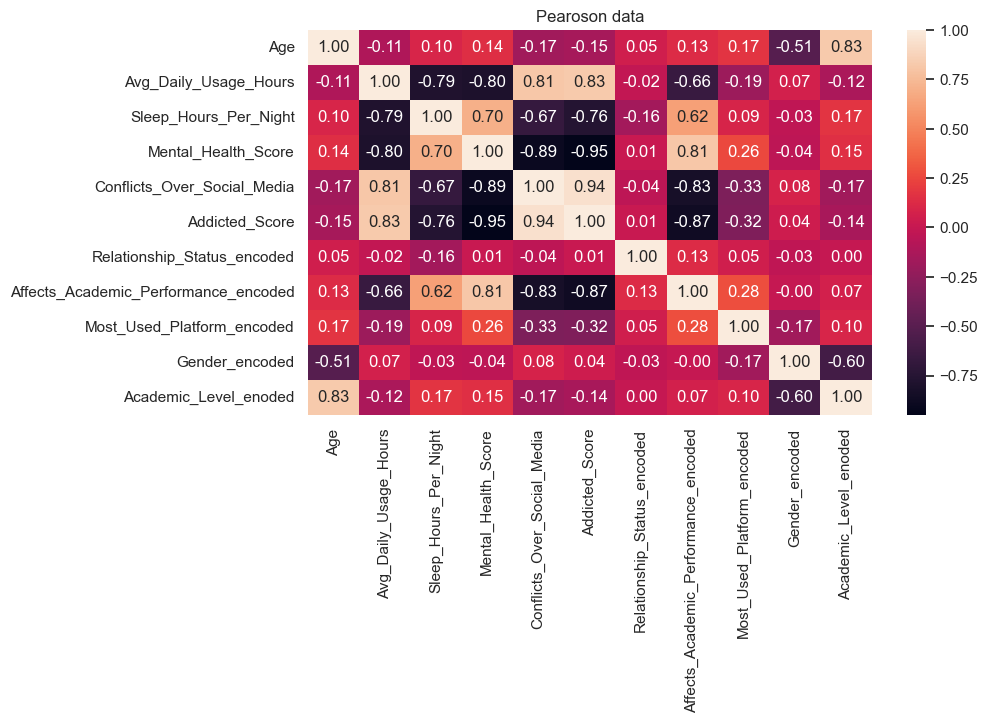

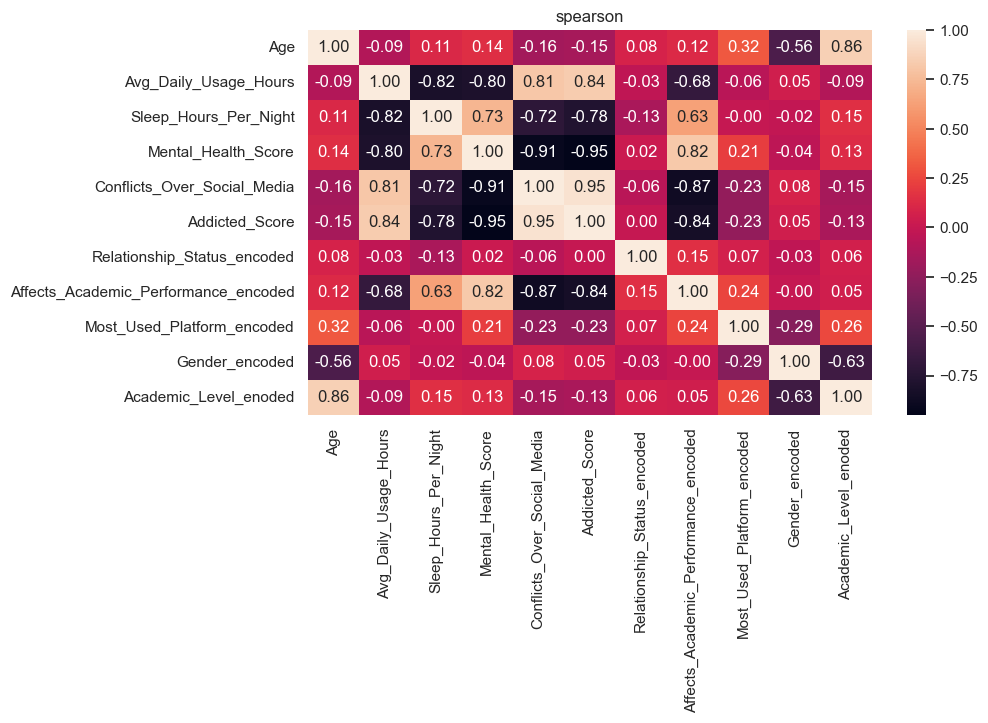

<Figure size 640x480 with 0 Axes>

In [135]:
col1=['#ff4d01','#ffffff']


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.set_theme(style='white',palette=col1)
sns.heatmap(pearson1,cbar=True,fmt=".2f",annot=True)
plt.title("Pearoson data")
plt.show()

plt.figure(figsize=(20,5))
plt.subplot(1,2,2)
sns.set_theme(style='white',palette=col1)
sns.heatmap(spearmen1,cbar=True,annot=True,fmt=".2f")
plt.title("spearson")
plt.show()


plt.tight_layout()
plt.show()

In [136]:
x.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score',
       'Relationship_Status_encoded', 'Most_Used_Platform_encoded',
       'Gender_encoded', 'Academic_Level_enoded'],
      dtype='object')

In [ ]:
list(y)

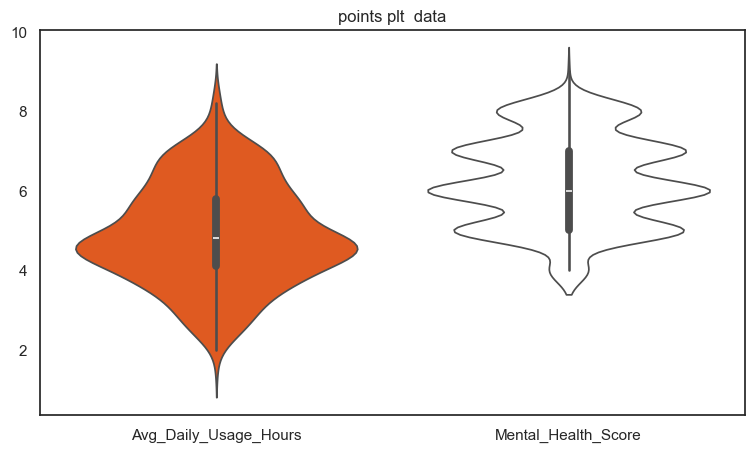

In [164]:
col1=['#ff4d01','#ffffff']


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.set_theme(style='white',palette=col1)
sns.violinplot(df5[['Avg_Daily_Usage_Hours','Mental_Health_Score']])
plt.title("points plt  data")
plt.savefig('p5.png',dpi=1000)
plt.show()

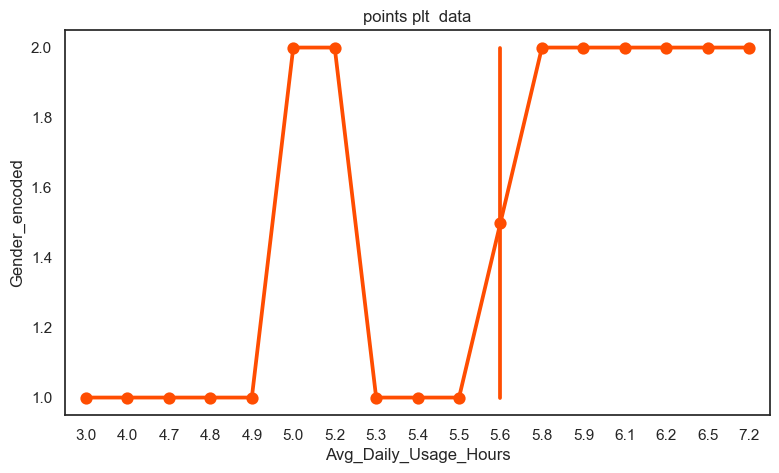

In [162]:
col1=['#ff4d01','#ffffff']


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.set_theme(style='white',palette=col1)
sns.pointplot(data=df5,x=df5['Avg_Daily_Usage_Hours'].head(20),y=df5['Gender_encoded'].head(20))
plt.title("points plt  data")
plt.savefig('p1.png',dpi=1000)
plt.show()

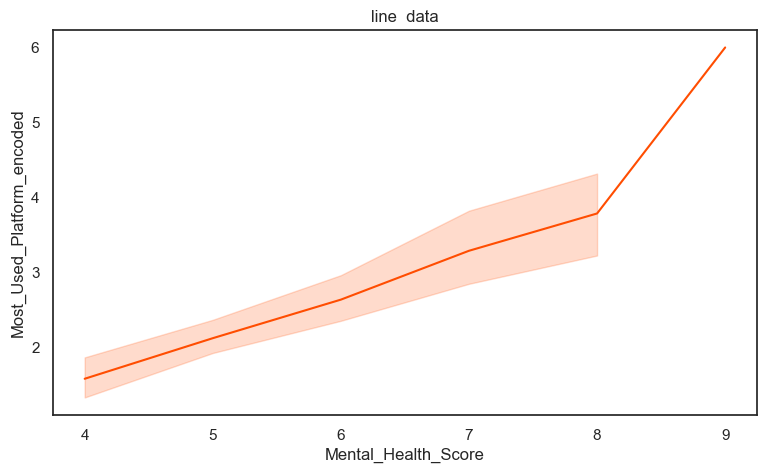

In [154]:
col1=['#ff4d01','#ffffff']


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.set_theme(style='white',palette=col1)
sns.lineplot(data=df5,x=df5['Mental_Health_Score'],y=df5['Most_Used_Platform_encoded'])
plt.title("line  data")
plt.savefig('p2.png',dpi=1000)
plt.show()

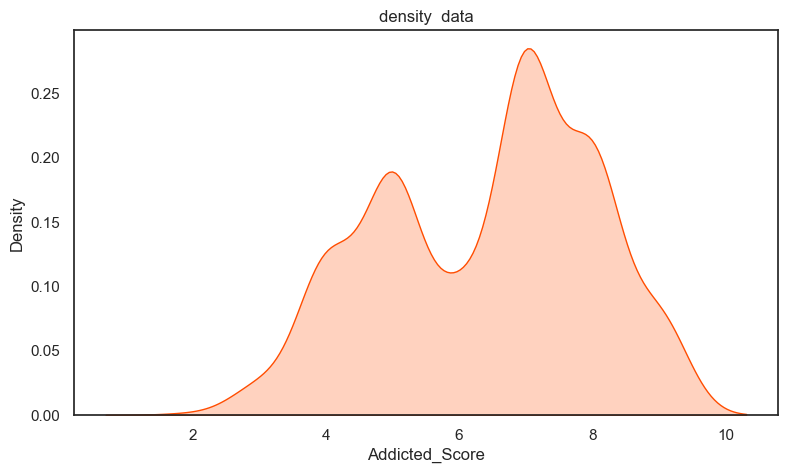

In [155]:
col1=['#ff4d01','#ffffff']


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.set_theme(style='white',palette=col1)
sns.kdeplot(df5['Addicted_Score'],fill=True)
plt.title("density  data")
plt.savefig('p3.png',dpi=1000)
plt.show()

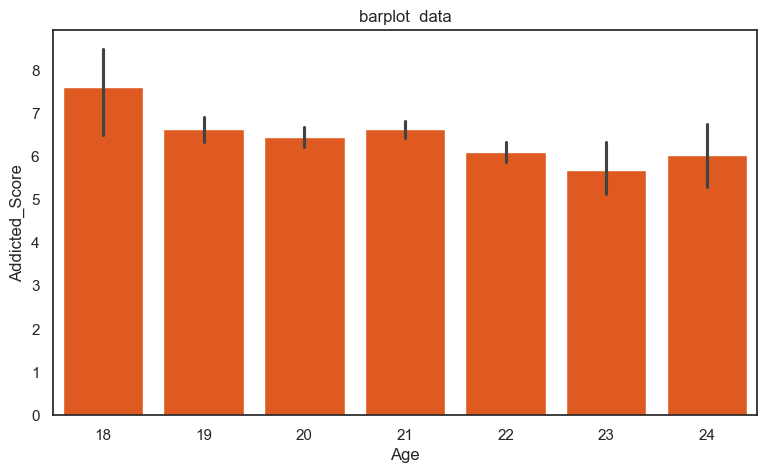

In [156]:
col1=['#ff4d01','#ffffff']


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.set_theme(style='white',palette=col1)
sns.barplot(data=df5,x=df5['Age'],y=df5['Addicted_Score'])
plt.title("barplot  data")
plt.savefig("p4.png",dpi=1000)
plt.show()

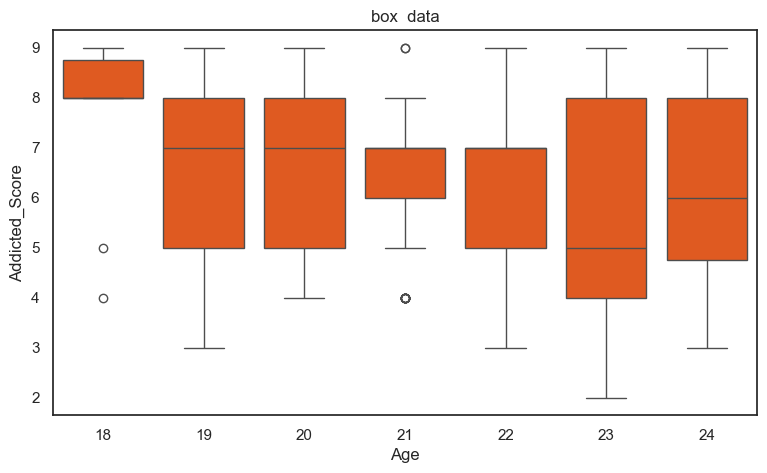

In [166]:
col1=['#ff4d01','#ffffff']


plt.figure(figsize=(20,5))
plt.subplot(1,2,1)
sns.set_theme(style='white',palette=col1)
sns.boxplot(data=df5,x=df5['Age'],y=df5['Addicted_Score'])
plt.title("box  data")
plt.savefig("p6.png",dpi=1000)
plt.show()

In [169]:
from sklearn.pipeline import Pipeline

model_dict=Pipeline(steps=[
    ("logistic_regression",logistic_regression)
])
model_dict1=Pipeline(steps=[
    ("Decesion_tree",Decesion_tree)
])

models={
    "logistic_regression":model_dict,
    "Decesion_tree":model_dict1
}


    

In [173]:
y

0      2
1      2
2      1
3      1
4      1
      ..
699    2
700    1
702    1
703    2
704    2
Name: Affects_Academic_Performance_encoded, Length: 676, dtype: int64

In [176]:
y.size

676

In [185]:
logistic_regression.fit(x_train,y_train)
y_logistic=logistic_regression.predict(x_test)
print(y_logistic)
print(accuracy_score(y_test,y_logistic))
print(classification_report(y_test,y_logistic))
print(f1_score(y_test,y_logistic))
print(logistic_regression.score(x_test,y_logistic))

[1 1 1 1 1 2 1 2 1 2 1 2 2 2 1 2 1 1 1 2 1 2 1 1 2 2 2 2 1 1 2 2 2 1 2 1 2
 1 1 1 1 1 2 1 1 1 1 2 2 1 1 2 2 1 1 2 1 2 1 1 1 1 1 1 2 2 1 2 1 1 1 1 2 2
 1 2 1 1 1 1 2 1 2 1 1 2 1 2 2 2 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1
 2 1 2 2 1 1 2 2 1 1 1 1 1 1 2 2 1 1 1 1 2 1 1 1 2]
1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        51

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136

1.0
1.0


In [186]:
Decesion_tree.fit(x_train,y_train)
y_decision=Decesion_tree.predict(x_test)
print(y_decision)
print(accuracy_score(y_test,y_decision))
print(classification_report(y_test,y_decision))
print(f1_score(y_test,y_decision))
print(Decesion_tree.score(x_test,y_decision))

[1 1 1 1 1 2 1 2 1 2 1 2 2 2 1 2 1 1 1 2 1 2 1 1 2 2 2 2 1 1 2 2 2 1 2 1 2
 1 1 1 1 1 2 1 1 1 1 2 2 1 1 2 2 1 1 2 1 2 1 1 1 1 1 1 2 2 1 2 1 1 1 1 2 2
 1 2 1 1 1 1 2 1 2 1 1 2 1 2 2 2 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1
 2 1 2 2 1 1 2 2 1 1 1 1 1 1 2 2 1 1 1 1 2 1 1 1 2]
1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        85
           2       1.00      1.00      1.00        51

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136

1.0
1.0


In [ ]:
# for name,model in models.items():
#     print(name)
#     model.fit(x_train,y_train)
#     y_logistic=model.predict(x_test)
#     print(y_logistic)
#     y_decision=model.predict(x_test)
#     print(y_decision)
#     print(model.score(x_test,y_logistic))

logistic_regression
[1 1 1 1 1 2 1 2 1 2 1 2 2 2 1 2 1 1 1 2 1 2 1 1 2 2 2 2 1 1 2 2 2 1 2 1 2
 1 1 1 1 1 2 1 1 1 1 2 2 1 1 2 2 1 1 2 1 2 1 1 1 1 1 1 2 2 1 2 1 1 1 1 2 2
 1 2 1 1 1 1 2 1 2 1 1 2 1 2 2 2 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1
 2 1 2 2 1 1 2 2 1 1 1 1 1 1 2 2 1 1 1 1 2 1 1 1 2]
[1 1 1 1 1 2 1 2 1 2 1 2 2 2 1 2 1 1 1 2 1 2 1 1 2 2 2 2 1 1 2 2 2 1 2 1 2
 1 1 1 1 1 2 1 1 1 1 2 2 1 1 2 2 1 1 2 1 2 1 1 1 1 1 1 2 2 1 2 1 1 1 1 2 2
 1 2 1 1 1 1 2 1 2 1 1 2 1 2 2 2 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1
 2 1 2 2 1 1 2 2 1 1 1 1 1 1 2 2 1 1 1 1 2 1 1 1 2]
1.0
Decesion_tree
[1 1 1 1 1 2 1 2 1 2 1 2 2 2 1 2 1 1 1 2 1 2 1 1 2 2 2 2 1 1 2 2 2 1 2 1 2
 1 1 1 1 1 2 1 1 1 1 2 2 1 1 2 2 1 1 2 1 2 1 1 1 1 1 1 2 2 1 2 1 1 1 1 2 2
 1 2 1 1 1 1 2 1 2 1 1 2 1 2 2 2 1 2 1 2 1 2 1 1 1 1 1 1 2 1 1 1 1 1 1 2 1
 2 1 2 2 1 1 2 2 1 1 1 1 1 1 2 2 1 1 1 1 2 1 1 1 2]
[1 1 1 1 1 2 1 2 1 2 1 2 2 2 1 2 1 1 1 2 1 2 1 1 2 2 2 2 1 1 2 2 2 1 2 1 2
 1 1 1 1 1 2 1 1 1 1 2 2 1 1 2 2 1 1 2 1 2 1 1 1 1 1 1 2

In [187]:
import joblib

joblib.dump(logistic_regression,"logstic.joblib")

['logstic.joblib']

In [188]:
joblib.dump(Decesion_tree,"Decesion.joblib")

['Decesion.joblib']

In [200]:
df5.columns

Index(['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score',
       'Relationship_Status_encoded', 'Affects_Academic_Performance_encoded',
       'Most_Used_Platform_encoded', 'Gender_encoded',
       'Academic_Level_enoded'],
      dtype='object')

'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score',
       'Relationship_Status_encoded'
       'Most_Used_Platform_encoded', 'Gender_encoded',
       'Academic_Level_enoded'

In [203]:
df5.describe()

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Relationship_Status_encoded,Affects_Academic_Performance_encoded,Most_Used_Platform_encoded,Gender_encoded,Academic_Level_enoded
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,20.665680,4.909467,6.884615,6.236686,2.847633,6.421598,1.480769,1.360947,2.806213,1.502959,2.430473
std,1.389081,1.269599,1.125568,1.115633,0.967093,1.600391,0.577029,0.480631,2.459031,0.500361,0.557418
min,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,19.750000,4.100000,6.000000,5.000000,2.000000,5.000000,1.000000,1.000000,1.000000,1.000000,2.000000
50%,21.000000,4.800000,7.000000,6.000000,3.000000,7.000000,1.000000,1.000000,2.000000,2.000000,2.000000
75%,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000,2.000000,2.000000,3.000000,2.000000,3.000000
max,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000,3.000000,2.000000,12.000000,2.000000,3.000000


In [ ]:
import pandas as pd 

import streamlit as st
import joblib
import warnings
warnings.filterwarnings("ignore")
import time


try:
    logistic=joblib.load("logstic.joblib")
    decesion=joblib.load("Decesion.joblib")
    st.balloons()
    st.header("Social Media Addtion or not")
    st.title("Decesion Tree + LOgistic [Classifiers]")
    st.code("Models are loaded succssfully")
    with st.sidebar.form(key="form-inputs"):
        with st.sidebar:
            st.info("this is the side bar section")
            st.header("Choose the input parameters")
            Age=st.number_input('Age',min_value=10,max_value=30,value=20)
            Avg_Daily_Usage_Hours=st.number_input('Avg_Daily_Usage_Hours',min_value=1,max_value=24,value=20)
            Sleep_Hours_Per_Night=st.number_input('Sleep_Hours_Per_Night',min_value=1,max_value=15,value=10)
            Mental_Health_Score=st.number_input('Mental_Health_Score',min_value=1,max_value=20,value=1)
            Conflicts_Over_Social_Media=st.number_input('Conflicts_Over_Social_Media',min_value=1,max_value=6,value=2)
            Addicted_Score=st.number_input('Addicted_Score',min_value=1,max_value=30,value=20)
            Relationship_Status_encoded=st.number_input('Relationship_Status_encoded',min_value=0,max_value=3,value=2)
            Most_Used_Platform_encoded=st.number_input('Most_Used_Platform_encoded',min_value=1,max_value=12,value=2)
            Gender_encoded=st.number_input('Gender_encoded',min_value=0,max_value=3,value=2)
            Academic_Level_enoded=st.number_input('Academic_Level_enoded',min_value=1,max_value=3,value=2)
            submit_button=st.form_submit_button(label="submit")
            if submit_button:
               with st.spinner("form is submitting"):
                   time.sleep(3)
                   st.info("form is submitted")
                   st.balloons()
            else:
                st.warning("form is not submitted")
    values_dict={
        'Age':Age, 
        'Avg_Daily_Usage_Hours':Avg_Daily_Usage_Hours, 
        'Sleep_Hours_Per_Night':Sleep_Hours_Per_Night,
        'Mental_Health_Score':Mental_Health_Score, 
        'Conflicts_Over_Social_Media':Conflicts_Over_Social_Media, 
        'Addicted_Score':Addicted_Score,
        'Relationship_Status_encoded':Relationship_Status_encoded, 
        'Most_Used_Platform_encoded':Most_Used_Platform_encoded, 
        'Gender_encoded':Gender_encoded,
        'Academic_Level_enoded':Academic_Level_enoded
    }
    df7=pd.DataFrame(data=values_dict,index=[0])
    predication1=logistic.predict(df7)
    st.code("if 1 means not affeted to acadamics and 2 means students are affected to acadamics ")
    st.code("Logistic regression results")
    st.code(f"the predication value is ===> {abs(predication1[0]):,.2f}")
    
    predication2=decesion.predict(df7)
    st.code("decesion tree classifier results")
    st.code(f"the predication value is ===> {abs(predication2[0]):,.2f}")
    
    st.subheader("data")
    st.data(df7)
    
    st.subheader("data editor")
    st.data_editor(df7)
    
    st.subheader("bar chart")
    st.bar_chart(df7)
    
    st.subheader("line chart")
    st.line_chart(df7)
            
            
            
            
            
except Exception as e:
    st.error(f"{str(e)}")
    st.code(f"{str(e)}",language='python')
else:
    st.info("no errors in the code")
finally:
    st.info("final block is executed irrespective the error code")

2026-01-02 18:07:53.498 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-02 18:07:53.499 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-02 18:07:53.500 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-02 18:07:53.501 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-02 18:07:53.501 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-02 18:07:53.502 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-02 18:07:53.502 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-02 18:07:53.503 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar